| 확인 항목                      | 왜 중요한가?              | 확인 방법                        |
| -------------------------- | -------------------- | ---------------------------- |
|  선형성(Linearity)           | X와 Y가 직선관계인지         | 산점도, Residual Plot           |
|  다중공선성(Multicollinearity) | 변수끼리 너무 비슷하면 계수가 불안정 | VIF, 상관계수                    |
|  잔차의 독립성                  | 오차끼리 영향이 없어야 함       | Durbin-Watson                |
|  등분산성(Homoscedasticity)   | 오차의 분산이 일정해야 함       | Residual Plot                |
|  잔차의 정규성                  | 가설검정과 신뢰구간 계산에 필요    | QQ Plot, Shapiro-Wilk        |
|  이상치(Outlier)             | 극단값이 회귀식을 왜곡         | Cook's Distance, Leverage    |
|  영향점(Influential Point)   | 몇 개의 데이터가 전체 결과를 좌우  | Cook's Distance              |
|  변수 선택                    | 필요 없는 변수를 제거         | p-value, AIC, BIC            |
|  과적합(Overfitting)         | 학습은 잘하지만 새로운 데이터에 약함 | Train/Test, Cross Validation |


<img src='lec_image/독립변수고려사항.png'>

<img src='lec_image/다중공선성.png'>

```text

① 데이터 준비
      ↓
② 산점도(선형성)
      ↓
③ 상관계수
      ↓
④ VIF(다중공선성)
      ↓
⑤ 회귀분석(OLS)
      ↓
⑥ p-value 확인
      ↓
⑦ 잔차 계산
      ↓
⑧ 등분산성
      ↓
⑨ 정규성
      ↓
⑩ 독립성(Durbin-Watson)
      ↓
⑪ 이상치
      ↓
⑫ Cook's Distance
      ↓
⑬ Train/Test 평가
      ↓
⑭ Cross Validation

데이터
          X1         X2          X3           y
0  67.640523  64.642773   92.616363  368.556394
1  54.001572  45.905897   95.212416  377.301509
2  59.787380  51.267672  121.993192  421.576063
3  72.408932  67.106832  113.105275  433.234672
4  68.675580  59.461775  112.802631  441.627747


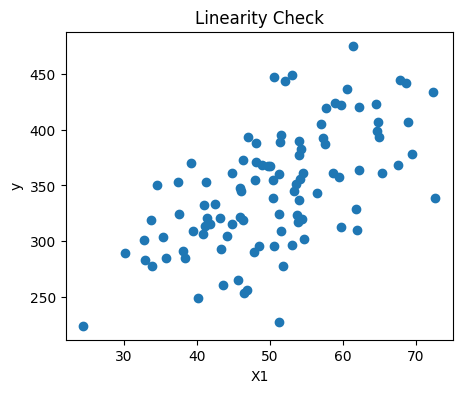

상관계수
          X1        X2        X3         y
X1  1.000000  0.976426  0.076116  0.608477
X2  0.976426  1.000000  0.084646  0.606321
X3  0.076116  0.084646  1.000000  0.793961
y   0.608477  0.606321  0.793961  1.000000


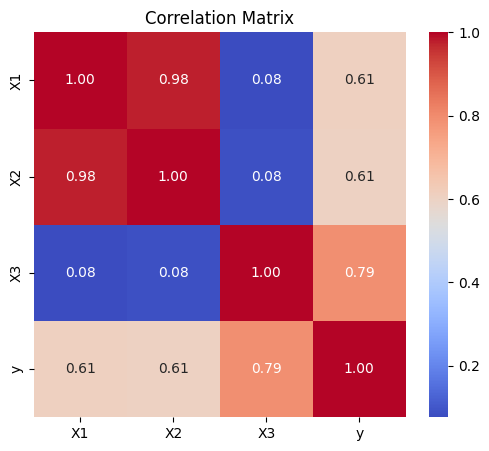

회귀분석 결과
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     444.9
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.67e-56
Time:                        13:38:50   Log-Likelihood:                -404.00
No. Observations:                 100   AIC:                             816.0
Df Residuals:                      96   BIC:                             826.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.8208      9.920     -0.688 

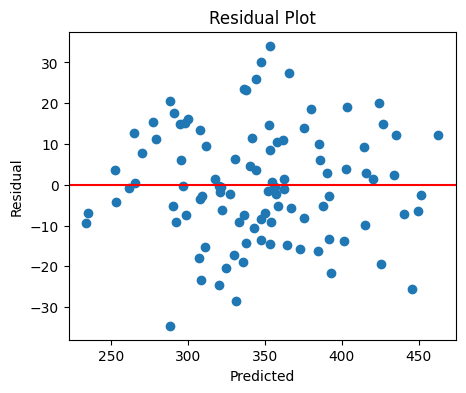

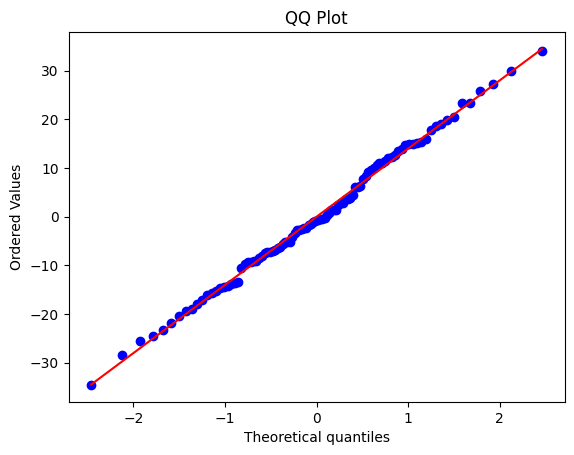

Shapiro-Wilk
Statistic : 0.9953523431539035
p-value   : 0.9831981980846808
→ 정규성 만족
Durbin-Watson : 2.075678468609929


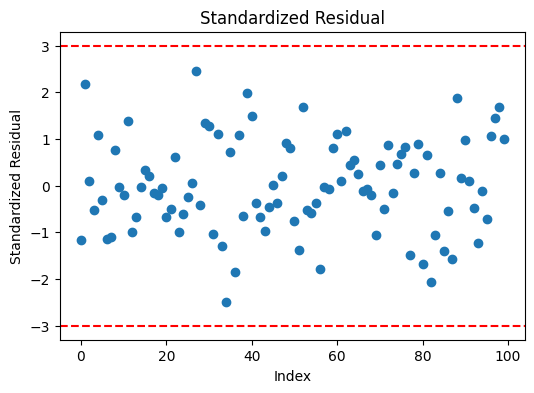

이상치 Index
[]


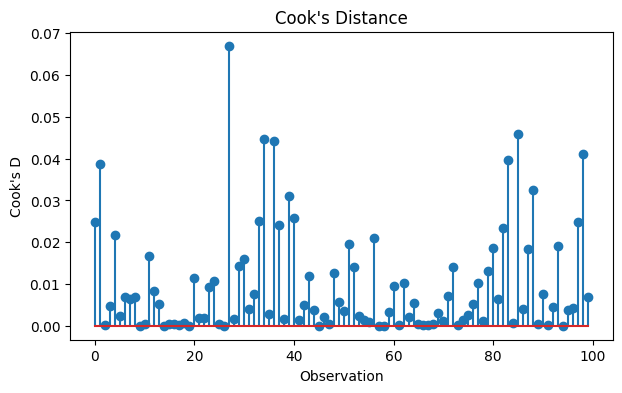

최대 Cook's Distance : 0.06704308097549096
Train R² : 0.9289261229381907
Test  R² : 0.9509591752715428
Cross Validation R²
[0.94329161 0.86739491 0.90905369 0.96745011 0.85390393]
평균 : 0.9082188509811298
분석 완료


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.stats import shapiro
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# ======================================================
# 1. 샘플 데이터 생성
# ======================================================
np.random.seed(0)

n = 100

X1 = np.random.normal(50, 10, n)

# X1과 매우 높은 상관관계 (다중공선성 발생)
X2 = X1 * 0.9 + np.random.normal(0, 2, n)

# 독립적인 변수
X3 = np.random.normal(100, 20, n)

# 종속변수
y = 3 * X1 + 2 * X3 + np.random.normal(0, 15, n)

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "y": y
})

print("=" * 60)
print("데이터")
print(df.head())

# ======================================================
# 2. 선형성 확인
# ======================================================
plt.figure(figsize=(5,4))
plt.scatter(df["X1"], df["y"])
plt.xlabel("X1")
plt.ylabel("y")
plt.title("Linearity Check")
plt.show()

# ======================================================
# 3. 상관계수 
# ======================================================
print("=" * 60)
print("상관계수")
print(df.corr())

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# ======================================================
# 4. 다중선형회귀
# ======================================================
X = df[["X1", "X2", "X3"]]
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print("=" * 60)
print("회귀분석 결과")
print(model.summary())

# ======================================================
# 5. VIF  다중공선성 확인(VIF)
# ======================================================
print("=" * 60)
print("VIF")

vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif)

# ======================================================
# 6. 예측값 및 잔차 :잔차계산
# ======================================================
pred = model.predict(X_const)
residual = y - pred

# ======================================================
# 7. 등분산성: 잔차가 일정하게 퍼짐(좋음),깔때기 모양( 나쁨)
# ======================================================
plt.figure(figsize=(5,4))
plt.scatter(pred, residual)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

# ======================================================
# 8. 정규성(QQ Plot): 잔차의 정규성 확인방법 1
# ======================================================
stats.probplot(residual, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

# ======================================================
# 9. Shapiro-Wilk: 잔차의 정규성 확인방법 2
# ======================================================
stat, p = shapiro(residual)

print("=" * 60)
print("Shapiro-Wilk")
print("Statistic :", stat)
print("p-value   :", p)

if p > 0.05:
    print("→ 정규성 만족")
else:
    print("→ 정규성 만족하지 않음")

# ======================================================
# 10. Durbin-Watson: 잔차의 독립성(Durbin-Watson)
# ======================================================
dw = durbin_watson(residual)

print("=" * 60)
print("Durbin-Watson :", dw)

# ======================================================
# 11. 표준화 잔차(이상치): 이상치 확인( |표준화잔차| > 3 ) 이면 이상치 의심
# ======================================================
std_residual = residual / residual.std()

plt.figure(figsize=(6,4))
plt.scatter(range(len(std_residual)), std_residual)
plt.axhline(3, color="red", linestyle="--")
plt.axhline(-3, color="red", linestyle="--")
plt.title("Standardized Residual")
plt.xlabel("Index")
plt.ylabel("Standardized Residual")
plt.show()

outliers = np.where(np.abs(std_residual) > 3)[0]

print("=" * 60)
print("이상치 Index")
print(outliers)

# ======================================================
# 12. Cook's Distance:영향점(Cook's Distance)
# ======================================================
influence = model.get_influence()
cooks = influence.cooks_distance[0]

plt.figure(figsize=(7,4))
plt.stem(range(len(cooks)), cooks)
plt.title("Cook's Distance")
plt.xlabel("Observation")
plt.ylabel("Cook's D")
plt.show()

print("=" * 60)
print("최대 Cook's Distance :", np.max(cooks))

# ======================================================
# 13. Train / Test:Train/Test 성능 확인
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

lr = LinearRegression()
lr.fit(X_train, y_train)

print("=" * 60)
print("Train R² :", lr.score(X_train, y_train))
print("Test  R² :", lr.score(X_test, y_test))

# ======================================================
# 14. Cross Validation: 교차검증(Cross Validation)
# ======================================================
scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("=" * 60)
print("Cross Validation R²")
print(scores)   
print("평균 :", scores.mean())

print("=" * 60)
print("분석 완료")

### 범주형데이터처리

<img src='lec_image/범주형처리.png'>

In [2]:
import pandas as pd

df = pd.DataFrame({
    "성별": ["남", "여", "여", "남", "남"],
    "혈액형": ["A", "B", "O", "AB", "A"],
    "지역": ["서울", "부산", "서울", "대구", "부산"],
    "만족도": ["낮음", "보통", "높음", "보통", "높음"],
    "매출": [100, 150, 120, 80, 170]
})

print(df)

  성별 혈액형  지역 만족도   매출
0  남   A  서울  낮음  100
1  여   B  부산  보통  150
2  여   O  서울  높음  120
3  남  AB  대구  보통   80
4  남   A  부산  높음  170


In [3]:


# 1. Label Encoding

# 범주를 숫자로 변환합니다.


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["성별_Label"] = le.fit_transform(df["성별"])

print(df)

  성별 혈액형  지역 만족도   매출  성별_Label
0  남   A  서울  낮음  100         0
1  여   B  부산  보통  150         1
2  여   O  서울  높음  120         1
3  남  AB  대구  보통   80         0
4  남   A  부산  높음  170         0


In [4]:
# 2. One-Hot Encoding
# 범주마다 새로운 컬럼을 만듭니다.


onehot = pd.get_dummies(df["혈액형"], prefix="혈액형")
print(onehot)

   혈액형_A  혈액형_AB  혈액형_B  혈액형_O
0   True   False  False  False
1  False   False   True  False
2  False   False  False   True
3  False    True  False  False
4   True   False  False  False


In [5]:
## 합치기
df1 = pd.concat([df, onehot], axis=1)
df1

,성별,혈액형,지역,만족도,매출,성별_Label,혈액형_A,혈액형_AB,혈액형_B,혈액형_O
0,남,A,서울,낮음,100,0,True,False,False,False
1,여,B,부산,보통,150,1,False,False,True,False
2,여,O,서울,높음,120,1,False,False,False,True
3,남,AB,대구,보통,80,0,False,True,False,False
4,남,A,부산,높음,170,0,True,False,False,False


In [9]:
# 3. Frequency Encoding

# 등장 빈도를 숫자로 바꿉니다.

freq = df["지역"].value_counts(normalize=True)

print(freq)

df["지역_Freq"] = df["지역"].map(freq)

df[["지역","지역_Freq"]]

지역
서울    0.4
부산    0.4
대구    0.2
Name: proportion, dtype: float64


,지역,지역_Freq
0,서울,0.4
1,부산,0.4
2,서울,0.4
3,대구,0.2
4,부산,0.4


In [8]:
# 4. Target Encoding

# 매출 평균으로 변환합니다.
target_mean = df.groupby("지역")["매출"].mean()

print(target_mean)

df["지역_Target"] = df["지역"].map(target_mean)

df[["지역","지역_Target"]]

지역
대구     80.0
부산    160.0
서울    110.0
Name: 매출, dtype: float64


,지역,지역_Target
0,서울,110.0
1,부산,160.0
2,서울,110.0
3,대구,80.0
4,부산,160.0


In [10]:
# 5. Ordinal Encoding

# 순서가 있는 데이터에 사용합니다.

order = {
    "낮음":0,
    "보통":1,
    "높음":2
}

df["만족도_Ordinal"] = df["만족도"].map(order)

df[["만족도","만족도_Ordinal"]]

,만족도,만족도_Ordinal
0,낮음,0
1,보통,1
2,높음,2
3,보통,1
4,높음,2


예시 출력

| 성별 | 혈액형 | 지역 | 만족도 |  매출 | 성별_Label | 혈액형_A | 혈액형_B | 혈액형_O | 혈액형_AB | 지역_Freq | 지역_Target | 만족도_Ordinal |
| -- | --- | -- | --- | --: | -------: | ----: | ----: | ----: | -----: | ------: | --------: | ----------: |
| 남  | A   | 서울 | 낮음  | 100 |        0 |     1 |     0 |     0 |      0 |     0.4 |       110 |           0 |
| 여  | B   | 부산 | 보통  | 150 |        1 |     0 |     1 |     0 |      0 |     0.4 |       160 |           1 |
| 여  | O   | 서울 | 높음  | 120 |        1 |     0 |     0 |     1 |      0 |     0.4 |       110 |           2 |
| 남  | AB  | 대구 | 보통  |  80 |        0 |     0 |     0 |     0 |      1 |     0.2 |        80 |           1 |
| 남  | A   | 부산 | 높음  | 170 |        0 |     1 |     0 |     0 |      0 |     0.4 |       160 |           2 |

---

## 어떤 인코딩을 언제 사용할까?

| 데이터 종류                    | 추천 방법                                             |
| ------------------------- | ------------------------------------------------- |
| 성별(2개 범주)                 | Label Encoding                                    |
| 혈액형, 지역(순서 없음)            | One-Hot Encoding                                  |
| 만족도(낮음·보통·높음)             | Ordinal Encoding                                  |
| 범주가 매우 많음(예: 수천 개의 상품 ID) | Frequency Encoding                                |
| 범주와 타깃의 관계를 활용하고 싶음       | Target Encoding *(데이터 누수 방지를 위해 교차검증 기반으로 적용 권장)* |


### 이상치 처리

<img src='lec_image/결측치.png'>

In [11]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer, KNNImputer

print("="*70)
print("1. 샘플 데이터 생성")
print("="*70)

df = pd.DataFrame({
    "나이":[20,25,np.nan,30,28],
    "키":[170,np.nan,180,175,172],
    "성별":["남","여",np.nan,"남","여"],
    "지역":["서울","부산","서울",np.nan,"부산"]
})

print(df)

# ======================================================
# 2. 결측치 확인
# ======================================================

print("\n" + "="*70)
print("2. 결측치 확인")
print("="*70)

print(df.isnull())

print("\n결측치 개수")
print(df.isnull().sum())

print("\n결측치 비율(%)")
print(df.isnull().mean()*100)

# ======================================================
# 3. 행 삭제
# ======================================================

print("\n" + "="*70)
print("3. 결측치 행 삭제")
print("="*70)

print(df.dropna())

# ======================================================
# 4. 열 삭제
# ======================================================

print("\n" + "="*70)
print("4. 결측치 열 삭제")
print("="*70)

print(df.dropna(axis=1))

# ======================================================
# 5. 평균으로 채우기
# ======================================================

print("\n" + "="*70)
print("5. 평균으로 대체")
print("="*70)

df_mean = df.copy()

df_mean["나이"] = df_mean["나이"].fillna(
    df_mean["나이"].mean()
)

print(df_mean)

# ======================================================
# 6. 중앙값으로 채우기
# ======================================================

print("\n" + "="*70)
print("6. 중앙값으로 대체")
print("="*70)

df_median = df.copy()

df_median["키"] = df_median["키"].fillna(
    df_median["키"].median()
)

print(df_median)

# ======================================================
# 7. 최빈값으로 채우기
# ======================================================

print("\n" + "="*70)
print("7. 최빈값으로 대체")
print("="*70)

df_mode = df.copy()

df_mode["성별"] = df_mode["성별"].fillna(
    df_mode["성별"].mode()[0]
)

print(df_mode)

# ======================================================
# 8. 특정 값으로 대체
# ======================================================

print("\n" + "="*70)
print("8. 특정 값으로 대체")
print("="*70)

df_fill = df.copy()

df_fill["지역"] = df_fill["지역"].fillna("미상")

print(df_fill)

# ======================================================
# 9. Forward Fill
# ======================================================

print("\n" + "="*70)
print("9. Forward Fill")
print("="*70)

df_ffill = df.copy().ffill()

print(df_ffill)

# ======================================================
# 10. Backward Fill
# ======================================================

print("\n" + "="*70)
print("10. Backward Fill")
print("="*70)

df_bfill = df.copy().bfill()

print(df_bfill)

# ======================================================
# 11. 선형보간
# ======================================================

print("\n" + "="*70)
print("11. 선형보간")
print("="*70)

df_interp = df.copy()

df_interp["나이"] = df_interp["나이"].interpolate()

print(df_interp)

# ======================================================
# 12. 그룹 평균으로 채우기
# ======================================================

print("\n" + "="*70)
print("12. 그룹 평균으로 대체")
print("="*70)

df2 = pd.DataFrame({
    "성별":["남","남","여","여"],
    "키":[170,np.nan,160,165]
})

print("원본")
print(df2)

df2["키"] = df2.groupby("성별")["키"].transform(
    lambda x: x.fillna(x.mean())
)

print("\n변환 후")
print(df2)

# ======================================================
# 13. SimpleImputer
# ======================================================

print("\n" + "="*70)
print("13. SimpleImputer")
print("="*70)

df_simple = df.copy()

imp_mean = SimpleImputer(strategy="mean")

df_simple["나이"] = imp_mean.fit_transform(
    df_simple[["나이"]]
).ravel()

imp_mode = SimpleImputer(strategy="most_frequent")

df_simple["성별"] = imp_mode.fit_transform(
    df_simple[["성별"]]
).ravel()

print(df_simple)

# ======================================================
# 14. KNN Imputer
# ======================================================

print("\n" + "="*70)
print("14. KNNImputer")
print("="*70)

num = df[["나이","키"]]

knn = KNNImputer(n_neighbors=2)

filled = knn.fit_transform(num)

filled_df = pd.DataFrame(
    filled,
    columns=["나이","키"]
)

print(filled_df)

print("\n" + "="*70)
print("결측치 처리 예제 완료")
print("="*70)

1. 샘플 데이터 생성
     나이      키   성별   지역
0  20.0  170.0    남   서울
1  25.0    NaN    여   부산
2   NaN  180.0  NaN   서울
3  30.0  175.0    남  NaN
4  28.0  172.0    여   부산

2. 결측치 확인
      나이      키     성별     지역
0  False  False  False  False
1  False   True  False  False
2   True  False   True  False
3  False  False  False   True
4  False  False  False  False

결측치 개수
나이    1
키     1
성별    1
지역    1
dtype: int64

결측치 비율(%)
나이    20.0
키     20.0
성별    20.0
지역    20.0
dtype: float64

3. 결측치 행 삭제
     나이      키 성별  지역
0  20.0  170.0  남  서울
4  28.0  172.0  여  부산

4. 결측치 열 삭제
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]

5. 평균으로 대체
      나이      키   성별   지역
0  20.00  170.0    남   서울
1  25.00    NaN    여   부산
2  25.75  180.0  NaN   서울
3  30.00  175.0    남  NaN
4  28.00  172.0    여   부산

6. 중앙값으로 대체
     나이      키   성별   지역
0  20.0  170.0    남   서울
1  25.0  173.5    여   부산
2   NaN  180.0  NaN   서울
3  30.0  175.0    남  NaN
4  28.0  172.0    여   부산

7. 최빈값으로 대체
     나이      키 성별   지역
0  20.0  170.


#  결측치 처리 방법

| 방법              | 수치형 | 범주형 |       추천도      |
| --------------- | :-: | :-: | :------------: |
| `dropna()`      |  ✔  |  ✔  |       ⭐⭐       |
| 평균(`mean`)      |  ✔  |  ❌  |      ⭐⭐⭐⭐      |
| 중앙값(`median`)   |  ✔  |  ❌  |      ⭐⭐⭐⭐⭐     |
| 최빈값(`mode`)     |  ❌  |  ✔  |      ⭐⭐⭐⭐⭐     |
| `fillna("미상")`  |  ❌  |  ✔  |       ⭐⭐⭐      |
| `ffill()`       |  ✔  |  ✔  |   ⭐⭐⭐⭐ (시계열)   |
| `bfill()`       |  ✔  |  ✔  |    ⭐⭐⭐ (시계열)   |
| `interpolate()` |  ✔  |  ❌  | ⭐⭐⭐⭐⭐ (연속 데이터) |
| `SimpleImputer` |  ✔  |  ✔  |      ⭐⭐⭐⭐⭐     |
| `KNNImputer`    |  ✔  |  ❌  |      ⭐⭐⭐⭐      |



* **수치형 데이터**: 중앙값(`median`) 또는 평균(`mean`) 대체를 많이 사용. 이상치가 많다면 중앙값이 더 적합.
* **범주형 데이터**: 최빈값(`mode`) 또는 `"미상"`과 같은 별도 범주로 대체하는 경우가 많다.
* **시계열 데이터**: `ffill()`, `bfill()`, `interpolate()`를 많이 사용.
* **머신러닝 파이프라인**: `SimpleImputer`나 `KNNImputer`를 사용하면 전처리와 모델 학습을 일관되게 구성하기 쉽다.

### 정규화

```text

- 경사하강법은 필수임
스케일이 크게 다르면 업데이트 양이 변수마다 달라진다.

예를 들어
나이
← 조금 이동
연봉
← 크게 이동

지그재그로 움직이고
수렴이 느려지고
심하면 발산할 수도 있다.


- LinearRegression에서도 정규화를 하는 이유는?

필수는 아니지만 다음과 같은 장점이 있다.

계수(회귀계수)의 크기를 서로 비교하기 쉬움
Ridge, Lasso, ElasticNet처럼 규제(Regularization)가 있는 모델에서는 성능이 더 좋아짐
PCA 등 다른 전처리와 함께 사용할 때 일관성이 있음
```

<img src='lec_image/정규화.png'>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler,
    Normalizer,
    FunctionTransformer
)

print("="*70)
print("1. 샘플 데이터")
print("="*70)

df = pd.DataFrame({
    "키":[160,165,170,175,180],
    "몸무게":[50,60,70,90,120]
})

print(df)

# =====================================================
# Min-Max Scaling
# =====================================================

print("\n"+"="*70)
print("2. Min-Max Scaling")
print("="*70)

scaler = MinMaxScaler()

minmax = scaler.fit_transform(df)

print(pd.DataFrame(
    minmax,
    columns=df.columns
))

# =====================================================
# Standard Scaling (Z-score)
# =====================================================

print("\n"+"="*70)
print("3. StandardScaler")
print("="*70)

scaler = StandardScaler()

standard = scaler.fit_transform(df)

print(pd.DataFrame(
    standard,
    columns=df.columns
))

# 평균과 표준편차 확인
print("\n평균")
print(np.mean(standard, axis=0))

print("\n표준편차")
print(np.std(standard, axis=0))

# =====================================================
# Robust Scaling
# =====================================================

print("\n"+"="*70)
print("4. RobustScaler")
print("="*70)

scaler = RobustScaler()

robust = scaler.fit_transform(df)

print(pd.DataFrame(
    robust,
    columns=df.columns
))

# =====================================================
# MaxAbs Scaling
# =====================================================

print("\n"+"="*70)
print("5. MaxAbsScaler")
print("="*70)

scaler = MaxAbsScaler()

maxabs = scaler.fit_transform(df)

print(pd.DataFrame(
    maxabs,
    columns=df.columns
))

# =====================================================
# Log Scaling
# =====================================================

print("\n"+"="*70)
print("6. Log Scaling")
print("="*70)

transformer = FunctionTransformer(np.log1p)

log = transformer.transform(df)

print(pd.DataFrame(
    log,
    columns=df.columns
))

# =====================================================
# L2 Normalization
# =====================================================

print("\n"+"="*70)
print("7. L2 Normalization")
print("="*70)

normalizer = Normalizer(norm="l2")

l2 = normalizer.fit_transform(df)

print(pd.DataFrame(
    l2,
    columns=df.columns
))

# =====================================================
# L1 Normalization
# =====================================================

print("\n"+"="*70)
print("8. L1 Normalization")
print("="*70)

normalizer = Normalizer(norm="l1")

l1 = normalizer.fit_transform(df)

print(pd.DataFrame(
    l1,
    columns=df.columns
))

# =====================================================
# 결과 비교
# =====================================================

print("\n"+"="*70)
print("9. 원본 vs MinMax")
print("="*70)

compare = pd.DataFrame({
    "원본_몸무게":df["몸무게"],
    "MinMax":minmax[:,1],
    "ZScore":standard[:,1],
    "Robust":robust[:,1],
    "MaxAbs":maxabs[:,1],
    "Log":log["몸무게"]
})

print(compare)

print("\n"+"="*70)
print("정규화 완료")
print("="*70)